In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPProcessor
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Этап 1. Fine-tuning CLIP

## 1. Работа с данными

### 1.1. Загрузка данных

In [2]:
import kagglehub

path = kagglehub.dataset_download("nirmalsankalana/fashion-product-text-images-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1


In [3]:
df = pd.read_csv(path + '/data.csv')

print("Первые строки датасета:")
print(df.head())
print(f"\nРазмер датасета: {len(df)} записей")
print(f"\nИнформация о столбцах:")
print(df.info())

# Проверка на дубликаты и пропуски
print(f"\nДубликаты: {df.duplicated().sum()}")
print(f"Пропуски в image: {df['image'].isna().sum()}")
print(f"Пропуски в description: {df['description'].isna().sum()}")

Первые строки датасета:
       image                                        description  \
0   3238.jpg  Round toed, black sports shoes with red accent...   
1  43044.jpg  Style Note Built with the breathability and ze...   
2  54018.jpg  Teal  handbag that has stitch detailing with a...   
3   8141.jpg  Perfectly stylish, this fastrack analog wrist ...   
4  22245.jpg  These id mid-top chukka shoes add a fresh spin...   

                                        display name      category  
0         Puma Men Black 65CC Lo Ducati Sports Shoes  Sports Shoes  
1                      Nike Men Charcoal Grey Shorts        Shorts  
2                           Kiara Women Teal Handbag      Handbags  
3  Fastrack Women Freestyle Sports Analog Steel B...       Watches  
4                          ID Men Brown Casual Shoes  Casual Shoes  

Размер датасета: 44441 записей

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44441 entries, 0 to 44440
Data columns (total 4 colum

In [4]:
img_dir = os.path.join(path, 'data')

### 1.2. EDA

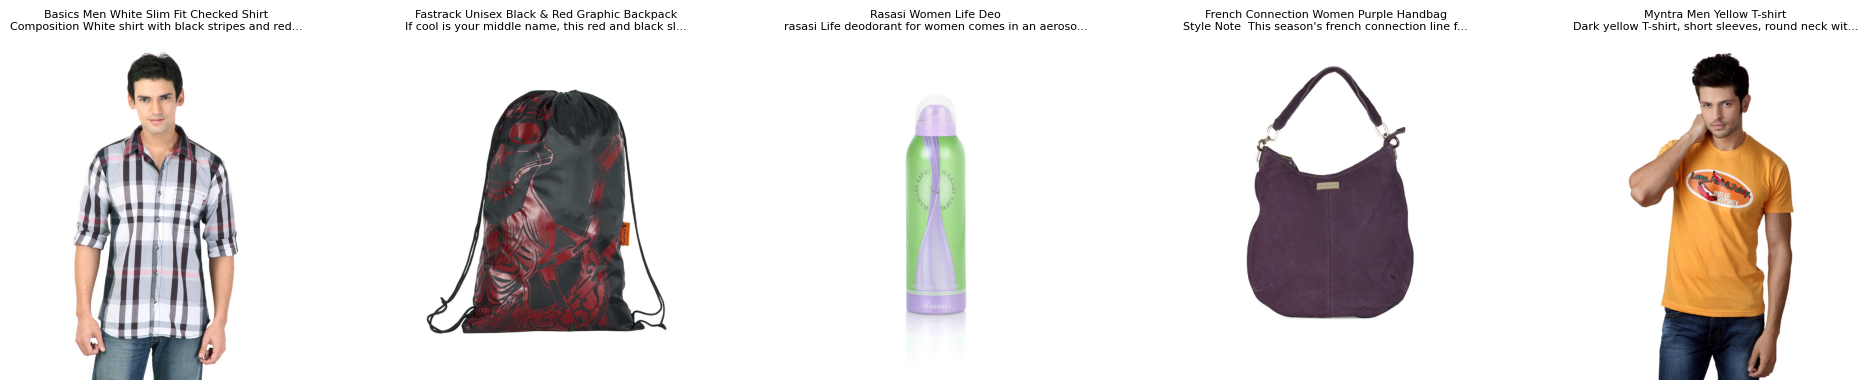

In [5]:
def visualize_samples(df, n=5):
    """Визуализация случайных примеров из датасета"""
    samples = df.sample(n)
    fig, axes = plt.subplots(1, n, figsize=(20, 4))
    if n == 1:
        axes = [axes]
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(img_dir, row['image'])
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].axis('off')
            axes[idx].set_title(f"{row['display name']}\n{row['description'][:50]}...", 
                               fontsize=8, pad=10)
    plt.tight_layout()
    plt.show()

# Визуализация примеров
visualize_samples(df, n=5)

In [6]:
# Анализ разрешений изображений
def analyze_image_resolutions(df):
    resolutions = []
    for idx, row in df.head(100).iterrows():
        img_path = os.path.join(img_dir, row['image'])
        if os.path.exists(img_path):
            with Image.open(img_path) as img:
                resolutions.append(img.size)
    
    print(f"Примеры разрешений: {resolutions[:10]}")
    return resolutions

resolutions = analyze_image_resolutions(df)

Примеры разрешений: [(1080, 1440), (1080, 1440), (1080, 1440), (1080, 1440), (1080, 1440), (1080, 1440), (1080, 1440), (1080, 1440), (1080, 1440), (1080, 1440)]


### 1.3. Формирование данных

In [7]:
def preprocess_data(df):
    """Предобработка датасета"""
    # Удаление дубликатов
    df = df.drop_duplicates(subset=['image'])
    
    # Удаление строк с пропусками
    df = df.dropna(subset=['image', 'description'])
    
    # Удаление пустых строк
    df = df[df['description'].str.strip() != '']
    df = df[df['image'].str.strip() != '']
    
    # Сброс индекса
    df = df.reset_index(drop=True)
    
    print(f"Размер после предобработки: {len(df)}")
    return df

df_clean = preprocess_data(df)

Размер после предобработки: 44158


In [8]:
# Разделение на train и test (90/10)
train_df, test_df = train_test_split(df_clean, test_size=0.1, random_state=42)
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 39742, Test size: 4416


In [9]:
class FashionCLIPDataset(Dataset):
    """Кастомный датасет: возвращает сырые данные для корректного батчинга"""
    
    def __init__(self, df, max_length=77):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.max_length = max_length
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.img_dir, row['image'])
        image = Image.open(img_path).convert('RGB')
        
        return {
            'image': image,
            'text': str(row['description'])
        }

# Создание датасетов
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

train_dataset = FashionCLIPDataset(train_df)
test_dataset = FashionCLIPDataset(test_df)

In [10]:
def collate_fn(batch):
    """
    Кастомная функция для сбора батча.
    Возвращает списки изображений и текстов без попытки их стека.
    """
    images = [item['image'] for item in batch]  # Список PIL.Image
    texts = [item['text'] for item in batch]    # Список строк
    return {'image': images, 'text': texts}


# Создание DataLoader
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2,
    collate_fn=collate_fn
)

## 2. Работа с моделью

### 2.1. Загрузка модели

In [11]:
# Загрузка предобученной CLIP модели
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = model.to(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

### 2.2. Тестирование модели из коробки

In [12]:
def test_clip_scores(model, processor, df, img_dir, device, n_samples=5):
    model.eval()
    results = []
    samples = df.sample(n_samples, random_state=42)
    
    print(f"Тестируем {n_samples} примеров через предобученную CLIP...\n")
    
    with torch.no_grad():
        for idx, row in samples.iterrows():
            img_path = os.path.join(img_dir, row['image'])
            try:
                image = Image.open(img_path).convert('RGB')
            except Exception as e:
                print(f"Не удалось загрузить {row['image']}: {e}")
                continue
            
            text = row['description']
            
            # Процессинг
            inputs = processor(
                images=[image],
                text=[text],
                return_tensors="pt",
                padding=True,
                truncation=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            outputs = model(
                pixel_values=inputs['pixel_values'],
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask']
            )
            
            image_features = outputs.image_embeds
            text_features = outputs.text_embeds
            
            if image_features is None: image_features = outputs.pooler_output
            if text_features is None: text_features = outputs.pooler_output
            
            # Нормализация и вычисление косинусной схожести
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            
            clip_score = (image_features @ text_features.T).item()
            
            results.append({
                'image': row['image'],
                'description': text,
                'clip_score': clip_score
            })
            
            print(f"{row['image']}")
            print(f"   Текст: {text[:80]}{'...' if len(text) > 80 else ''}")
            print(f"   CLIP Score: {clip_score:.4f} ({clip_score*100:.2f}%)")
            print()
    
    if results:
        scores = [r['clip_score'] for r in results]
        print(f"   Статистика по {len(scores)} примерам:")
        print(f"   Средний: {sum(scores)/len(scores):.4f}")
        print(f"   Мин: {min(scores):.4f}, Макс: {max(scores):.4f}")
    
    return results

In [13]:
# Запуск теста
test_results = test_clip_scores(
    model=model,
    processor=processor,
    df=df_clean,  # ваш предобработанный датасет
    img_dir=img_dir,  # путь к папке с картинками
    device=device,
    n_samples=10  # количество примеров для теста
)

Тестируем 10 примеров через предобученную CLIP...

45789.jpg
   Текст: Style Note The Spanish influences in the design details of this sandal is the re...
   CLIP Score: 0.3223 (32.23%)

40970.jpg
   Текст: Style Note When you wear buckaroo shoes, you are making a style statement that i...
   CLIP Score: 0.3065 (30.65%)

20901.jpg
   Текст: Inspired by the primal attitudes these sandals from catwalk are an excellent sub...
   CLIP Score: 0.3195 (31.95%)

49496.jpg
   Текст: Round toed low-tops with four-hole lace-ups and stitch detail around the seams o...
   CLIP Score: 0.2918 (29.18%)

3402.jpg
   Текст: Composition Pure leather tote bag in yellow with same colour zippers and stitch ...
   CLIP Score: 0.3387 (33.87%)

55478.jpg
   Текст: Long-lasting, precise line to define lips Transfer resistant, sets in minutes fo...
   CLIP Score: 0.3223 (32.23%)

18451.jpg
   Текст: guess eau de parfum spray for women is created to celebrate the modern woman wit...
   CLIP Score: 0.2679 (26.79%)

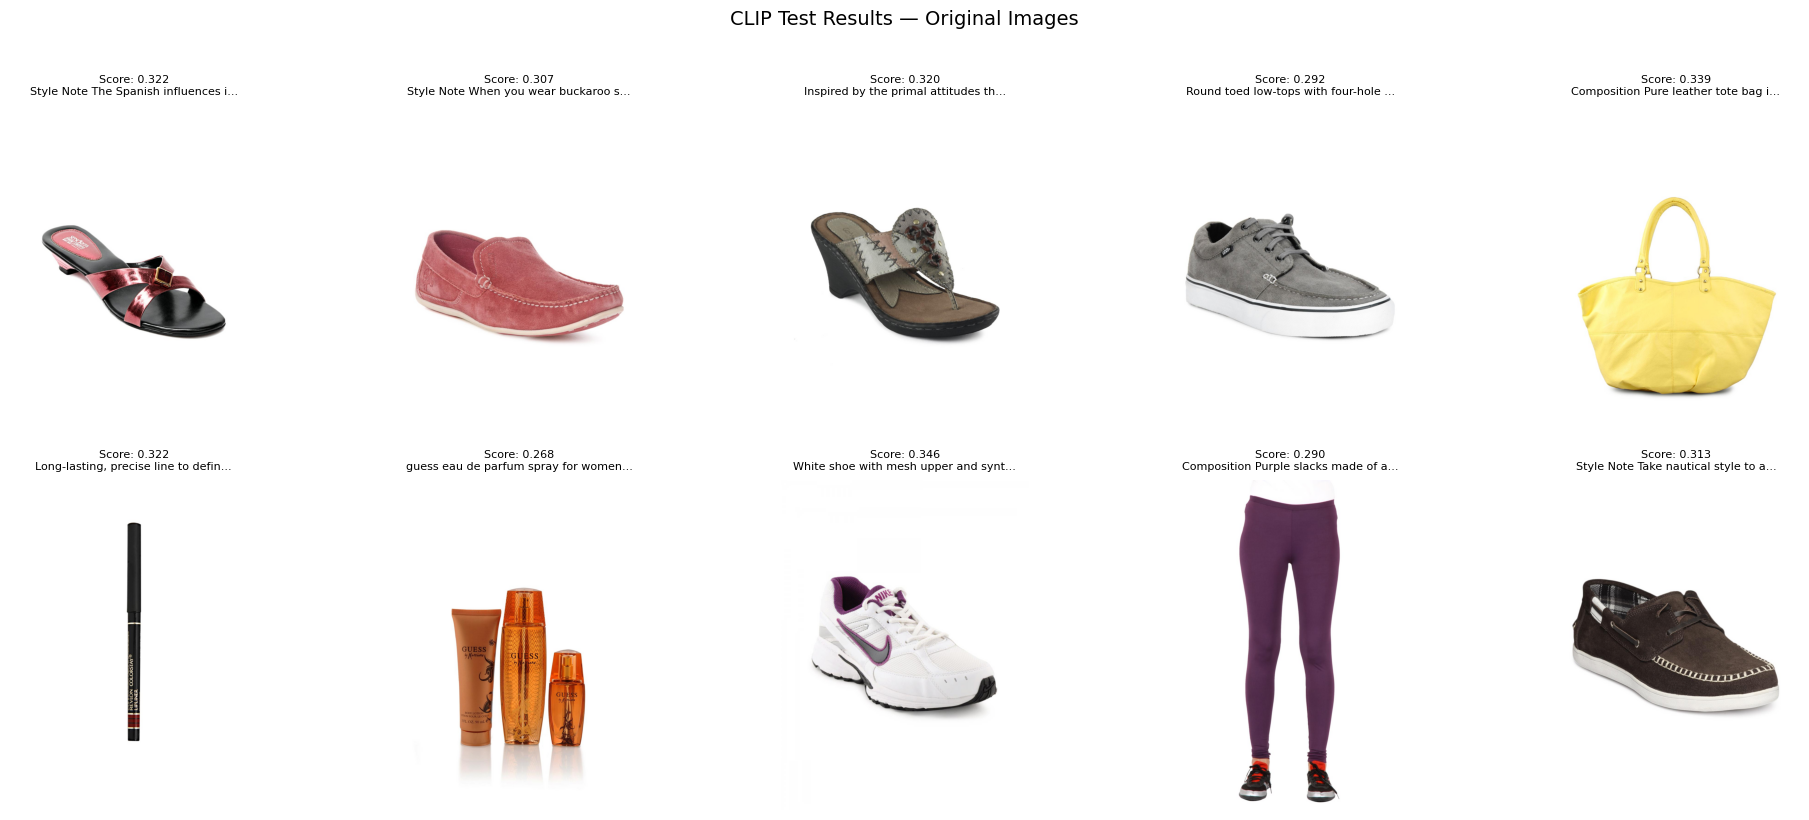

In [14]:
def visualize_test_results(results):
    """Визуализация примеров с их CLIP-скорами"""
    import os
    from PIL import Image
    import matplotlib.pyplot as plt
    
    n = len(results)
    if n == 0:
        print("Нет результатов для визуализации")
        return
    
    # Динамическое создание сетки подплотов
    cols = min(n, 5)
    rows = (n + cols - 1) // cols  # округление вверх
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    
    if n == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    else:
        axes = axes.flatten()
    
    for idx, res in enumerate(results):
        img_path = os.path.join(img_dir, res['image'])
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Не удалось загрузить {img_path}: {e}")
            img = Image.new('RGB', (224, 224), color='lightgray')
        
        axes[idx].imshow(img)
        axes[idx].axis('off')
        
        # Цветная рамка в зависимости от скоринга
        score = res['clip_score']
        edge_color = 'green' if score > 0.35 else 'orange' if score > 0.25 else 'red'
        for spine in axes[idx].spines.values():
            spine.set_edgecolor(edge_color)
            spine.set_linewidth(3)
        
        # Подпись
        title = f"Score: {score:.3f}\n{res['description'][:35]}..."
        axes[idx].set_title(title, fontsize=8, pad=8)
    
    # Скрыть пустые подплоты
    for idx in range(n, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle("CLIP Test Results — Original Images", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('clip_test_results_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()

# Визуализация
visualize_test_results(test_results)

# 3. Дообучение

In [15]:
class CLIPLoss(nn.Module):
    """Contrastive loss function для CLIP"""
    def __init__(self, device):
        super().__init__()
        self.device = device
        self.labels = None
        
    def forward(self, image_features, text_features, logit_scale):
        batch_size = image_features.shape[0]
        
        # Нормализация признаков
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        # Логиты (схожесть)
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()
        
        # Ground truth labels
        ground_truth = torch.arange(batch_size, dtype=torch.long, device=self.device)
        
        # Cross-entropy loss
        loss_i = nn.CrossEntropyLoss()(logits_per_image, ground_truth)
        loss_t = nn.CrossEntropyLoss()(logits_per_text, ground_truth)
        
        return (loss_i + loss_t) / 2

In [16]:
def extract_features(features_output):
    """
    Универсальное извлечение тензора признаков из вывода CLIP.
    """
    if hasattr(features_output, 'image_embeds'):
        return features_output.image_embeds
    elif hasattr(features_output, 'text_embeds'):
        return features_output.text_embeds
    elif hasattr(features_output, 'pooler_output'):
        return features_output.pooler_output
    elif hasattr(features_output, 'last_hidden_state'):
        # Берем [CLS] токен (первый)
        return features_output.last_hidden_state[:, 0, :]
    # Если уже тензор - возвращаем как есть
    return features_output

In [17]:
def train_epoch(model, dataloader, optimizer, device, log_interval=10):
    """Обучение с обработкой батча внутри цикла"""
    model.train()
    total_loss = 0
    total_clip_score = 0
    num_batches = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for batch_idx, batch in enumerate(progress_bar):
        # 1. Подготовка данных
        images = batch['image']  # Список PIL-изображений
        texts = batch['text']    # Список строк
        
        # 2. Обработка через processor (если передан)
        if processor is not None:
            inputs = processor(
                text=texts,
                images=images,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77
            )
            pixel_values = inputs['pixel_values'].to(device)
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
        else:
            # Если данные уже обработаны (для валидации)
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
        
        # 3. Forward pass
        optimizer.zero_grad()
        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_loss=True
        )
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        # 4. Логирование метрик
        total_loss += loss.item()
        num_batches += 1
        
        with torch.no_grad():
            # Получение признаков с универсальной обработкой
            image_features = extract_features(model.get_image_features(pixel_values=pixel_values))
            text_features = extract_features(model.get_text_features(input_ids=input_ids, attention_mask=attention_mask))
            
            # Нормализация
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            
            # CLIP score (косинусная схожесть)
            clip_score = (image_features * text_features).sum(dim=-1).mean().item()
            total_clip_score += clip_score
        
        if batch_idx % log_interval == 0:
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'score': f'{clip_score:.4f}'})
    
    return total_loss / num_batches, total_clip_score / num_batches

In [18]:
def validate(model, dataloader, device):
    """Валидация модели"""
    model.eval()
    total_clip_score = 0
    num_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            # Обработка данных (аналогично train_epoch)
            if processor is not None and 'image' in batch:
                images = batch['image']
                texts = batch['text']
                inputs = processor(
                    text=texts,
                    images=images,
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=77
                )
                pixel_values = inputs['pixel_values'].to(device)
                input_ids = inputs['input_ids'].to(device)
                attention_mask = inputs['attention_mask'].to(device)
            else:
                pixel_values = batch['pixel_values'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
            
            # Извлечение признаков
            image_features = extract_features(model.get_image_features(pixel_values=pixel_values))
            text_features = extract_features(model.get_text_features(input_ids=input_ids, attention_mask=attention_mask))
            
            # Нормализация и расчёт схожести
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            
            clip_score = (image_features * text_features).sum(dim=-1).mean().item()
            total_clip_score += clip_score
            num_batches += 1
    
    return total_clip_score / num_batches

In [21]:
# Параметры обучения
num_epochs = 3
learning_rate = 1e-5
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

In [22]:
# Инициализация оптимизатора
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Метрики для логирования
train_losses = []
train_clip_scores = []
val_clip_scores = []

print("Начало обучения...")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    
    # Обучение
    train_loss, train_score = train_epoch(model, train_loader, optimizer, device)
    train_losses.append(train_loss)
    train_clip_scores.append(train_score)
    
    # Валидация
    val_score = validate(model, test_loader, device)
    val_clip_scores.append(val_score)
    
    print(f"Epoch {epoch + 1}:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Train CLIP Score: {train_score:.4f}")
    print(f"  Val CLIP Score: {val_score:.4f}")
    
    # Сохранение чекпоинта
    checkpoint_path = os.path.join(checkpoint_dir, f'clip_epoch_{epoch + 1}.pt')
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'train_clip_score': train_score,
        'val_clip_score': val_score,
    }, checkpoint_path)
    print(f"  Checkpoint saved: {checkpoint_path}")

print("\nОбучение завершено!")

Начало обучения...

Epoch 1/3


Training: 100%|█| 1242/1242 [24:54<00:00,  1.20s/it, loss=0.18
Validating: 100%|███████████| 138/138 [01:48<00:00,  1.27it/s]


Epoch 1:
  Train Loss: 0.3602
  Train CLIP Score: 0.2913
  Val CLIP Score: 0.2904
  Checkpoint saved: checkpoints/clip_epoch_1.pt

Epoch 2/3


Training: 100%|█| 1242/1242 [25:24<00:00,  1.23s/it, loss=0.18
Validating: 100%|███████████| 138/138 [01:46<00:00,  1.29it/s]


Epoch 2:
  Train Loss: 0.2202
  Train CLIP Score: 0.3056
  Val CLIP Score: 0.2923
  Checkpoint saved: checkpoints/clip_epoch_2.pt

Epoch 3/3


Training: 100%|█| 1242/1242 [25:32<00:00,  1.23s/it, loss=0.18
Validating: 100%|███████████| 138/138 [01:46<00:00,  1.29it/s]


Epoch 3:
  Train Loss: 0.1640
  Train CLIP Score: 0.3123
  Val CLIP Score: 0.3119
  Checkpoint saved: checkpoints/clip_epoch_3.pt

Обучение завершено!


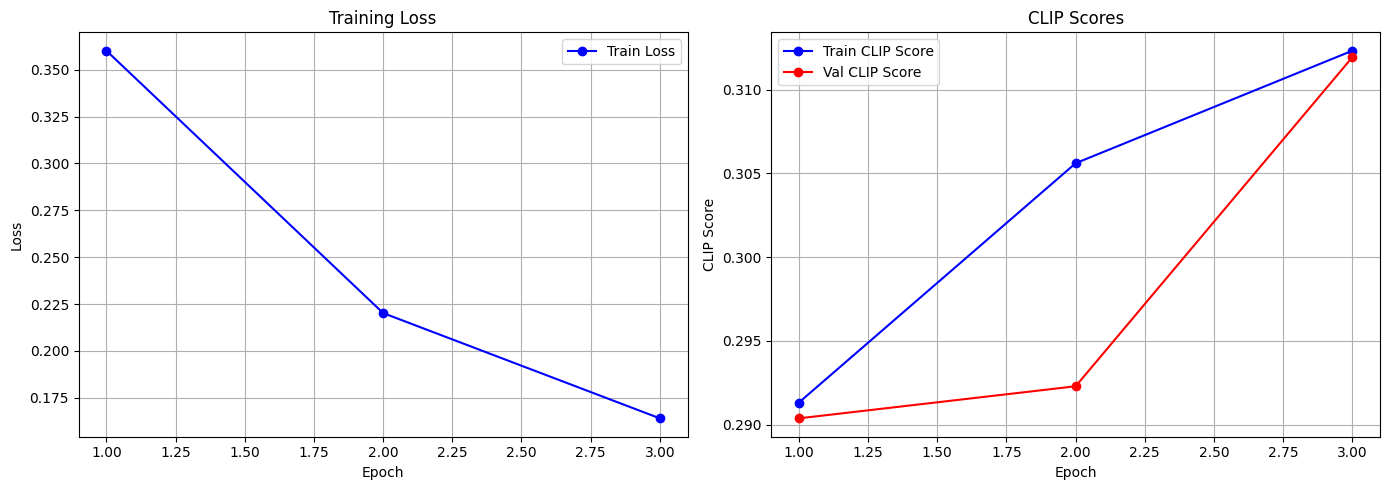


Финальные метрики:
  Final Train Loss: 0.1640
  Final Train CLIP Score: 0.3123
  Final Val CLIP Score: 0.3119
  Target CLIP Score > 30: ✗


In [23]:
def plot_training_curves(train_losses, train_scores, val_scores):
    """Визуализация кривых обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Кривая потерь
    axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].grid(True)
    axes[0].legend()
    
    # Кривые CLIP score
    axes[1].plot(range(1, len(train_scores) + 1), train_scores, 'b-o', label='Train CLIP Score')
    axes[1].plot(range(1, len(val_scores) + 1), val_scores, 'r-o', label='Val CLIP Score')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('CLIP Score')
    axes[1].set_title('CLIP Scores')
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=300)
    plt.show()

plot_training_curves(train_losses, train_clip_scores, val_clip_scores)

# Вывод финальных метрик
print(f"\nФинальные метрики:")
print(f"  Final Train Loss: {train_losses[-1]:.4f}")
print(f"  Final Train CLIP Score: {train_clip_scores[-1]:.4f}")
print(f"  Final Val CLIP Score: {val_clip_scores[-1]:.4f}")
print(f"  Target CLIP Score > 30: {'✓' if val_clip_scores[-1] > 30 else '✗'}")

# Этап 2: Реализация системы поиска товаров

## 2.1. Предварительное вычисление эмбеддингов изображений

In [24]:
# Загрузка лучшей модели
checkpoint = torch.load('checkpoints/clip_epoch_3.pt')
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [34]:
def compute_image_embeddings(model, df, processor, device, batch_size=64):
    """Вычисление эмбеддингов для всех изображений"""
    model.eval()
    all_embeddings = []
    
    dataset = FashionCLIPDataset(df)
    loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=2, 
        collate_fn=collate_fn
    )
    
    print("Вычисление эмбеддингов изображений...")
    with torch.no_grad():
        for batch in tqdm(loader):
            images = batch['image']
            
            # Обработка через processor
            inputs = processor(images=images, return_tensors="pt", padding=True)
            pixel_values = inputs['pixel_values'].to(device)
            
            # Получение и извлечение признаков
            raw_output = model.get_image_features(pixel_values=pixel_values)
            image_features = extract_features(raw_output)  # ← Ваша функция!
            
            # Нормализация
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            all_embeddings.append(image_features.cpu())
    
    return torch.cat(all_embeddings, dim=0)

# Вычисление эмбеддингов для всего датасета
print(f"Вычисление эмбеддингов для {len(df_clean)} изображений...")
image_embeddings = compute_image_embeddings(model, df_clean, processor, device)

Вычисление эмбеддингов для 44158 изображений...
Вычисление эмбеддингов изображений...


100%|███████████████████████| 690/690 [14:30<00:00,  1.26s/it]


In [35]:
# Сохранение эмбеддингов
torch.save(image_embeddings, 'image_embeddings.pt')
print(f"Эмбеддинги сохранены. Размер: {image_embeddings.shape}")

Эмбеддинги сохранены. Размер: torch.Size([44158, 512])


## 2.2. Функция поиска товаров

In [40]:
class FashionSearchSystem:
    """Система поиска товаров по текстовому запросу"""
    
    def __init__(self, model, processor, df, image_embeddings, device, img_dir):
        self.model = model.to(device)
        self.processor = processor
        self.df = df.reset_index(drop=True)
        self.image_embeddings = image_embeddings
        self.device = device
        self.img_dir = img_dir
        
    def encode_text(self, text_query):
        """Кодирование текстового запроса"""
        self.model.eval()
        with torch.no_grad():
            inputs = self.processor(
                text=[text_query],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77
            )
            input_ids = inputs['input_ids'].to(self.device)
            attention_mask = inputs['attention_mask'].to(self.device)
            
            # Получаем сырой вывод
            raw_output = self.model.get_text_features(
                input_ids=input_ids, 
                attention_mask=attention_mask
            )
            text_features = extract_features(raw_output)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            
        return text_features.cpu()
    
    def search(self, query, top_k=5):
        """Поиск товаров по текстовому запросу"""
        text_embedding = self.encode_text(query)  # [1, 512]
        
        # Вычисление схожести: [N, 512] @ [512, 1] = [N, 1]
        similarities = self.image_embeddings @ text_embedding.T
        similarities = similarities.squeeze()
        
        # Поиск top_k
        top_k = min(top_k, len(similarities))
        top_values, top_indices = torch.topk(similarities, top_k)
        
        # Формирование результата
        results = self.df.iloc[top_indices.numpy()].copy()
        results = results.reset_index(drop=True)
        results['similarity_score'] = top_values.numpy()
        results = results.sort_values('similarity_score', ascending=False).reset_index(drop=True)
        
        return results
    
    def visualize_results(self, query, top_k=5):
        """Поиск и визуализация результатов"""
        results = self.search(query, top_k)
        
        n = min(top_k, len(results))
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
        if n == 1:
            axes = [axes]
        
        for idx, (_, row) in enumerate(results.iterrows()):
            img_path = os.path.join(self.img_dir, row['image'])
            try:
                img = Image.open(img_path).convert('RGB')
            except:
                img = Image.new('RGB', (224, 224), color='gray')
            
            axes[idx].imshow(img)
            axes[idx].axis('off')
            score = row['similarity_score']
            title = f"Score: {score:.3f}\n{row['description'][:35]}..."
            axes[idx].set_title(title, fontsize=8, pad=10)
        
        plt.suptitle(f"Query: '{query}'", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        
        return results


search_system = FashionSearchSystem(
    model=model,
    processor=processor,
    df=df_clean,
    image_embeddings=image_embeddings,
    device=device,
    img_dir=img_dir
)

In [41]:
# Загрузка эмбеддингов
image_embeddings = torch.load('image_embeddings.pt')


Query: 'red skirt'
----------------------------------------


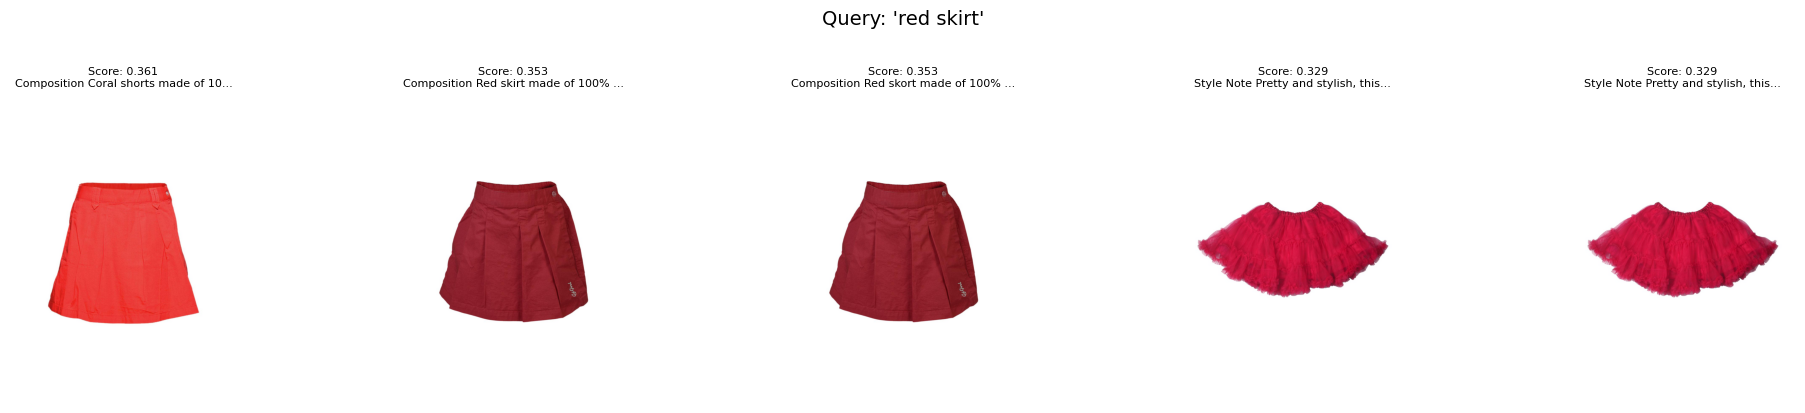

  1. [0.361] Composition Coral shorts made of 100% cotton, with elasticat...
  2. [0.353] Composition Red skirt made of 100% cotton, has an elasticate...
  3. [0.353] Composition Red skort made of 100% cotton, has an elasticate...

Query: 'blue sunglasses'
----------------------------------------


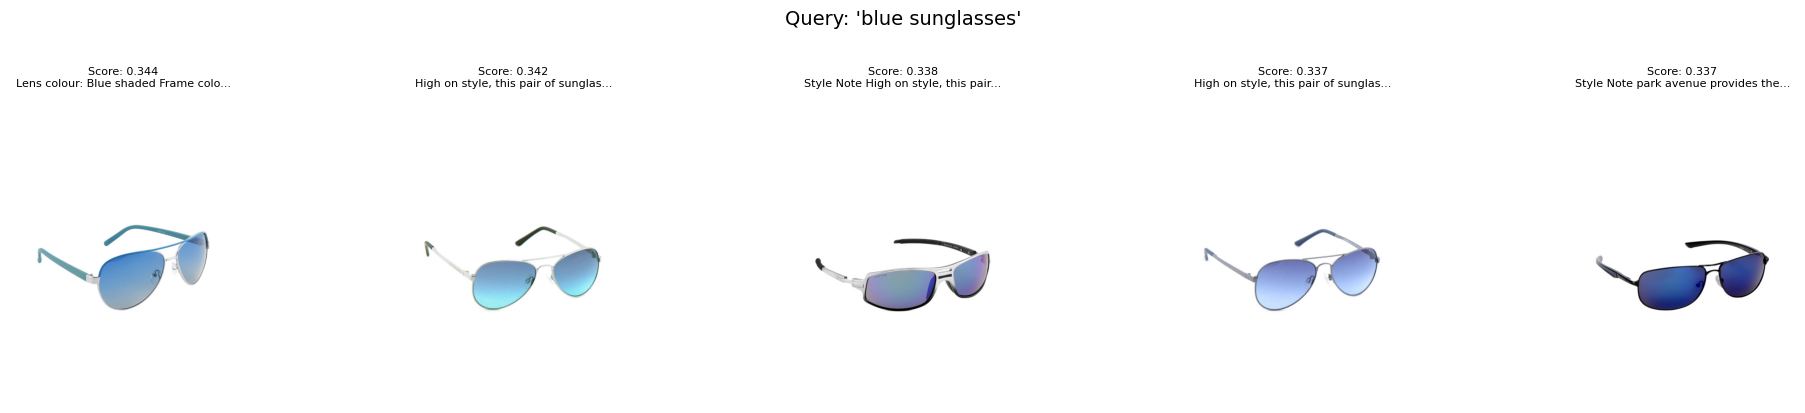

  1. [0.344] Lens colour: Blue shaded Frame colour: Silver and blue Frame...
  2. [0.342] High on style, this pair of sunglasses from united colors of...
  3. [0.338] Style Note High on style, this pair of distortion free sungl...

Query: 'mickey mouse'
----------------------------------------


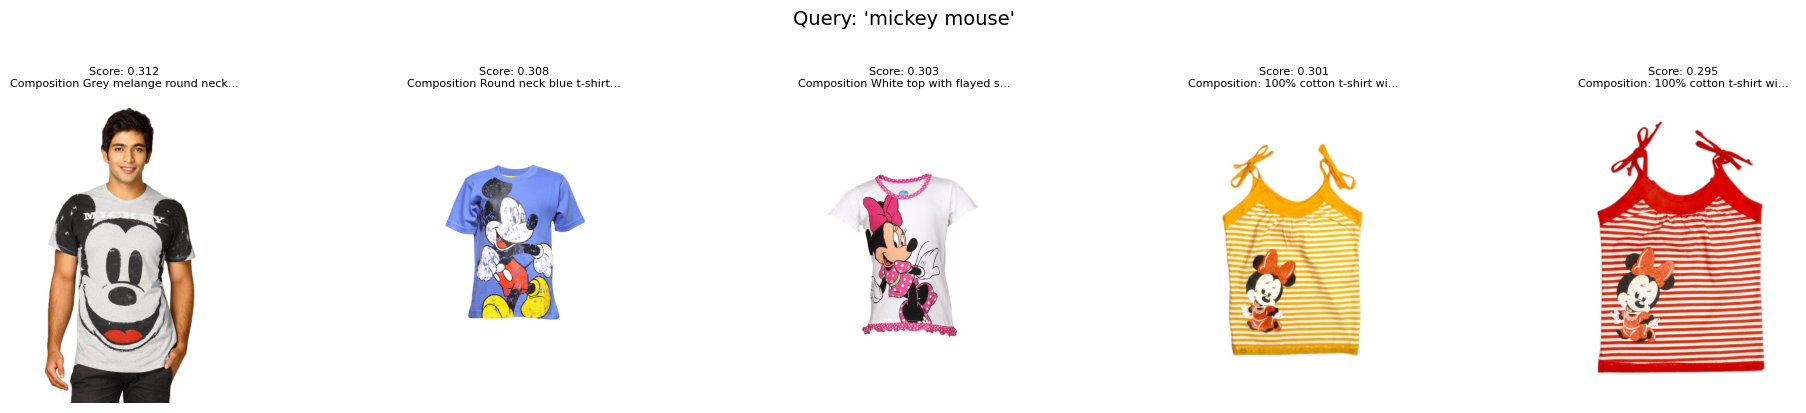

  1. [0.312] Composition Grey melange round neck t-shirt made of 100% cot...
  2. [0.308] Composition Round neck blue t-shirt in 100% cotton, with mic...
  3. [0.303] Composition White top with flayed sleeves, white and pink po...

Query: 'black leather jacket'
----------------------------------------


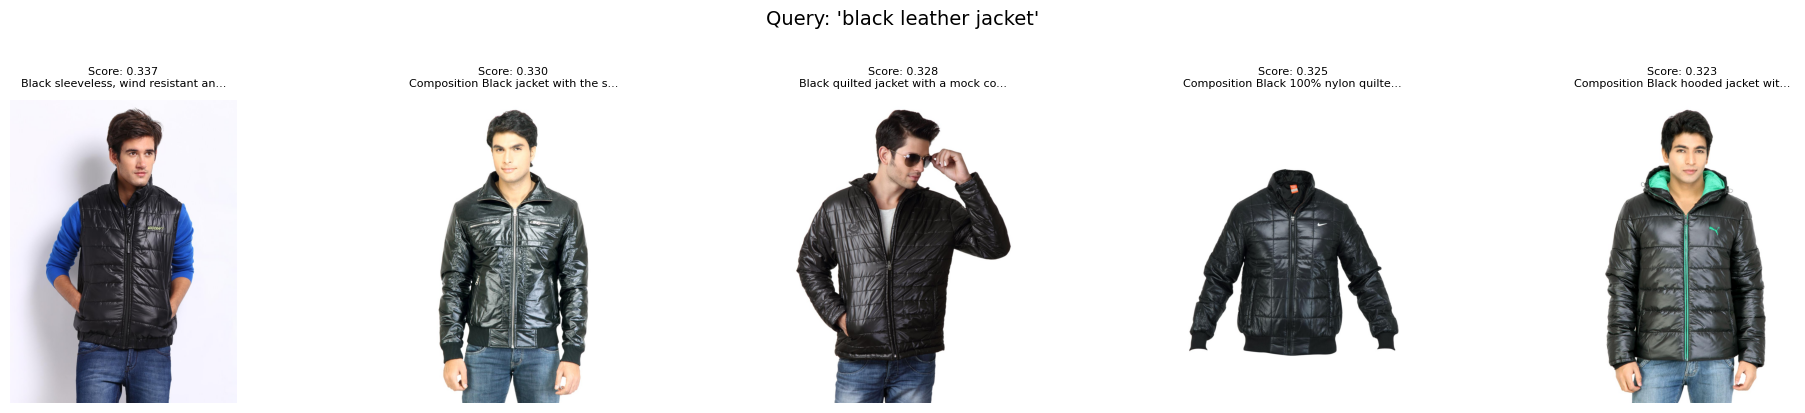

  1. [0.337] Black sleeveless, wind resistant and water repellent jacket ...
  2. [0.330] Composition Black jacket with the shell made of 100% cotton ...
  3. [0.328] Black quilted jacket with a mock collar, padded interlining,...

Query: 'white summer dress'
----------------------------------------


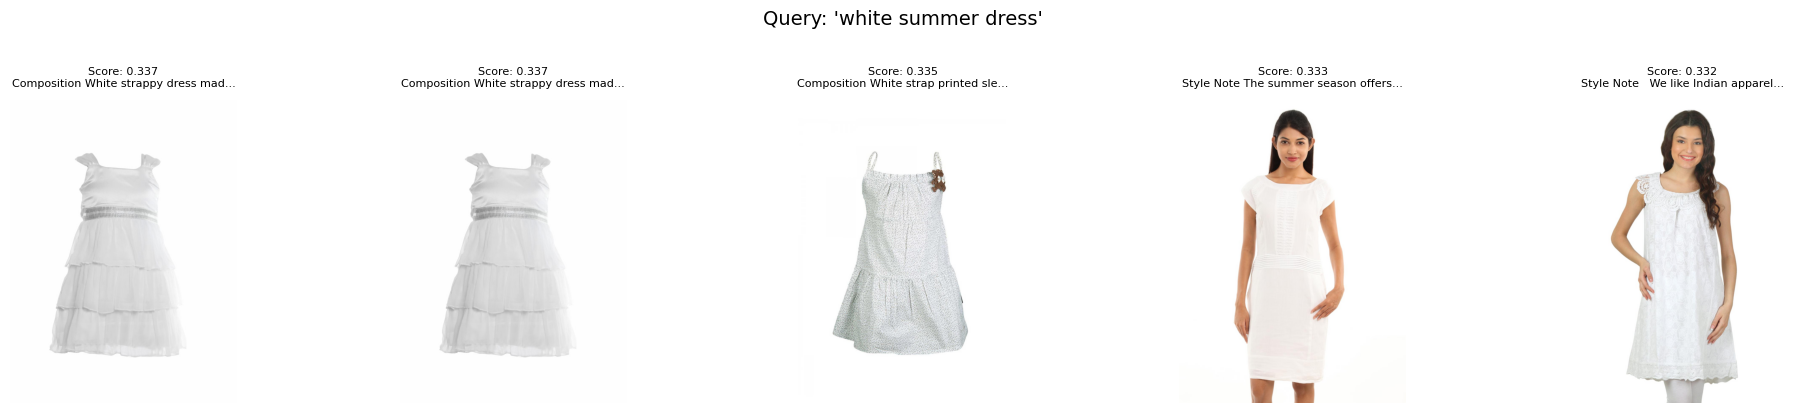

  1. [0.337] Composition White strappy dress made of blended satin fabric...
  2. [0.337] Composition White strappy dress made of blended satin fabric...
  3. [0.335] Composition White strap printed sleeveless dress, made of 10...

Query: 'sports shoes'
----------------------------------------


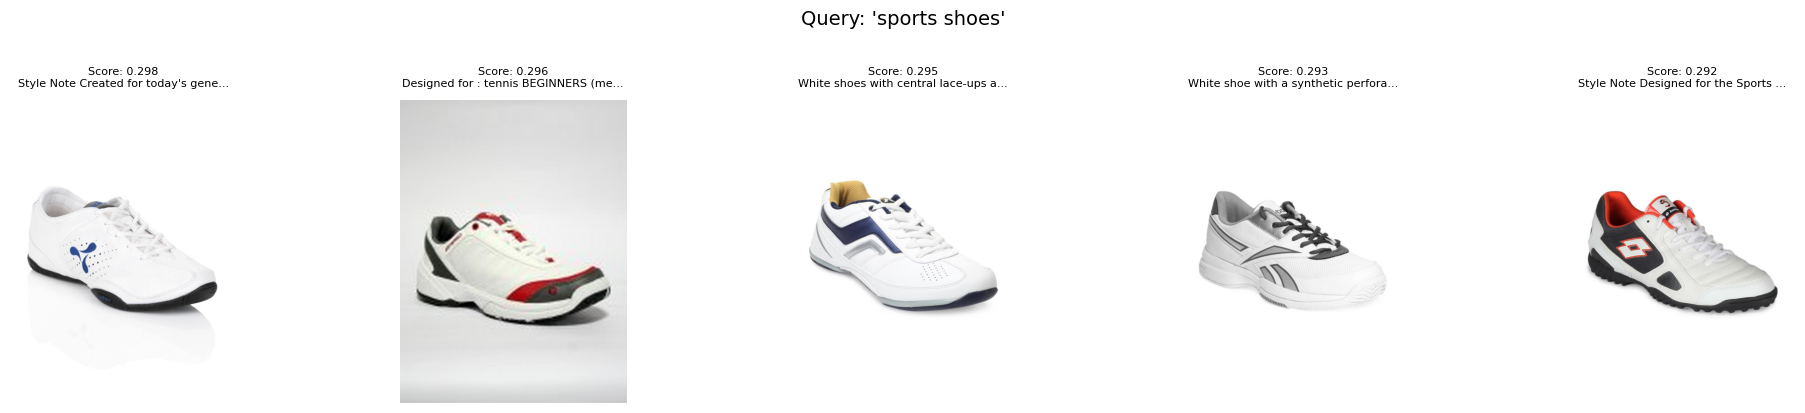

  1. [0.298] Style Note Created for today's generation, this spinn Brash ...
  2. [0.296] Designed for : tennis BEGINNERS (men) who play REGULARLY on ...
  3. [0.295] White shoes with central lace-ups and perforations for venti...

Query: 'wool sweater'
----------------------------------------


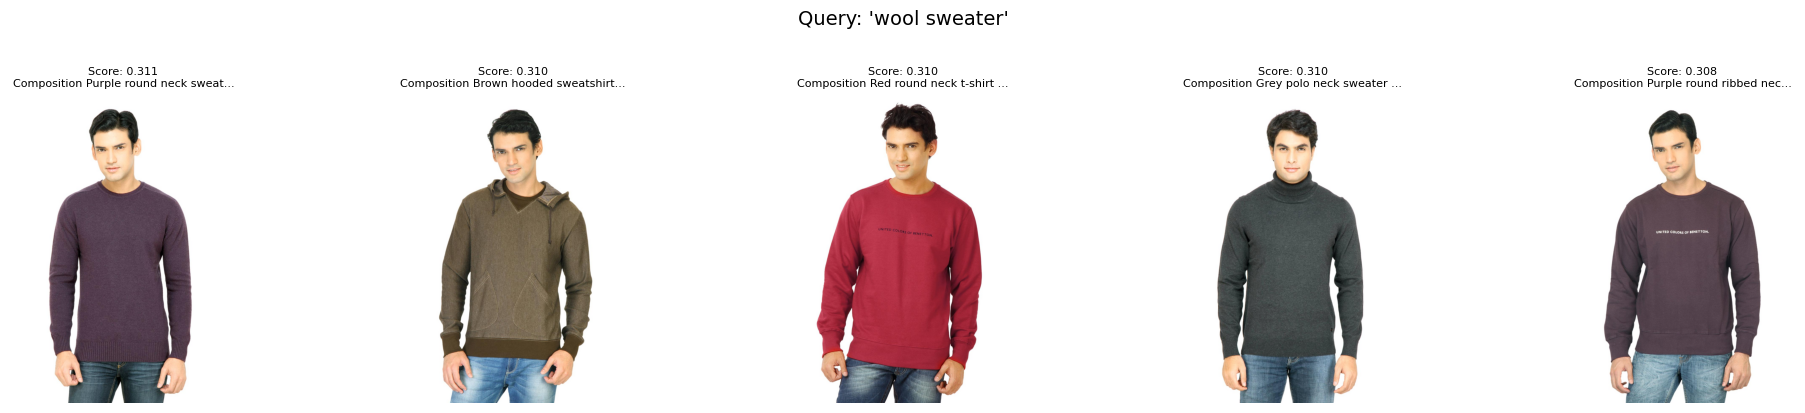

  1. [0.311] Composition Purple round neck sweater made of 80% lambswool ...
  2. [0.310] Composition Brown hooded sweatshirt made of 85% cotton and 1...
  3. [0.310] Composition Red round neck t-shirt made of 80% cotton and 20...

Query: 'elegant evening gown'
----------------------------------------


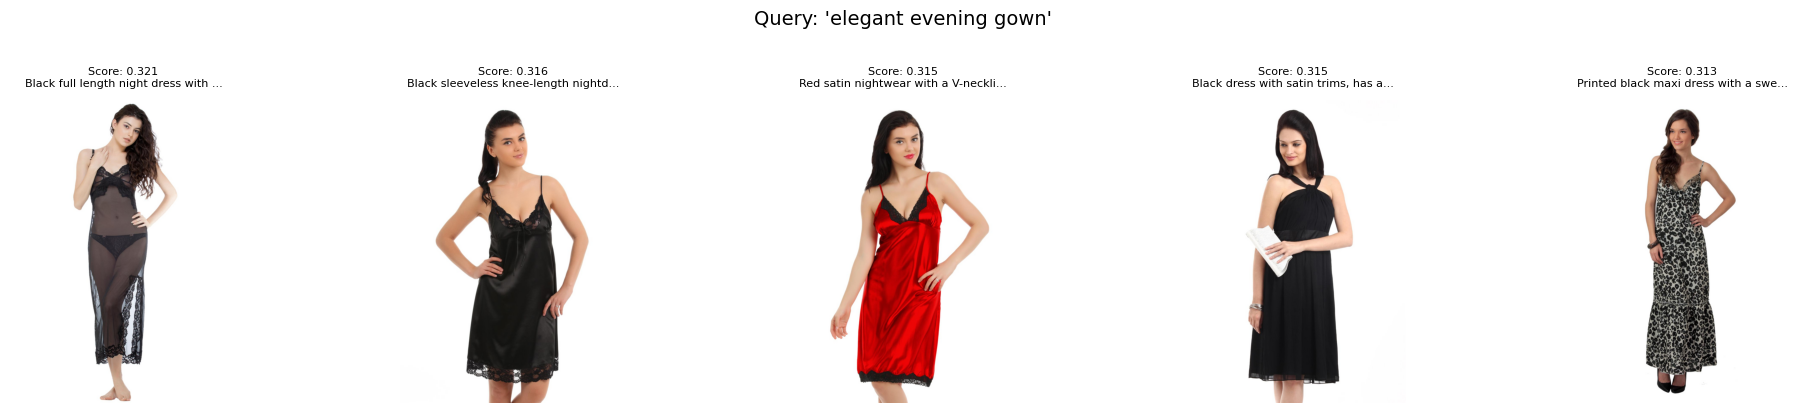

  1. [0.321] Black full length night dress with a side slit Has a V-neckl...
  2. [0.316] Black sleeveless knee-length nightdress with a V-neck, adjus...
  3. [0.315] Red satin nightwear with a V-neckline with lace detail, adju...


In [42]:
# Тестовые запросы
test_queries = [
    "red skirt",
    "blue sunglasses", 
    "mickey mouse",
    "black leather jacket",
    "white summer dress",
    "sports shoes",
    "wool sweater",
    "elegant evening gown"
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-"*40)
    results = search_system.visualize_results(query, top_k=5)
    for i, (_, row) in enumerate(results.head(3).iterrows(), 1):
        print(f"  {i}. [{row['similarity_score']:.3f}] {row['description'][:60]}...")